## WORLD HAPPINESS EXPLANATORY DATA ANALYSIS
## What will we learn from this project?
+ Bivariate data analysis
+ Multivaried data analysis
+ Seaborn library visualization techniques: bar, box, swarm , heatmap, clustermap
+ Plotly library visualization techniques animated plot and world map 

  ## Introduction
+ The World Happiness is a landmark survey of the state of global happiness.
+ The report continues to gain recognition as governments, organizations, and civil society increasingly use happiness indicators to inform their policity-making
decisions.
+ Leading experts across fields - economics, psychology, survey analysis, national statistics,health,public policy and more-
describe how measurements of well-being can be used effectively to asses the progress of nations.
+ The reports rewiev the state of happiness in the world today and show how the new science of happiness 
explains personal and national variation in happiness.


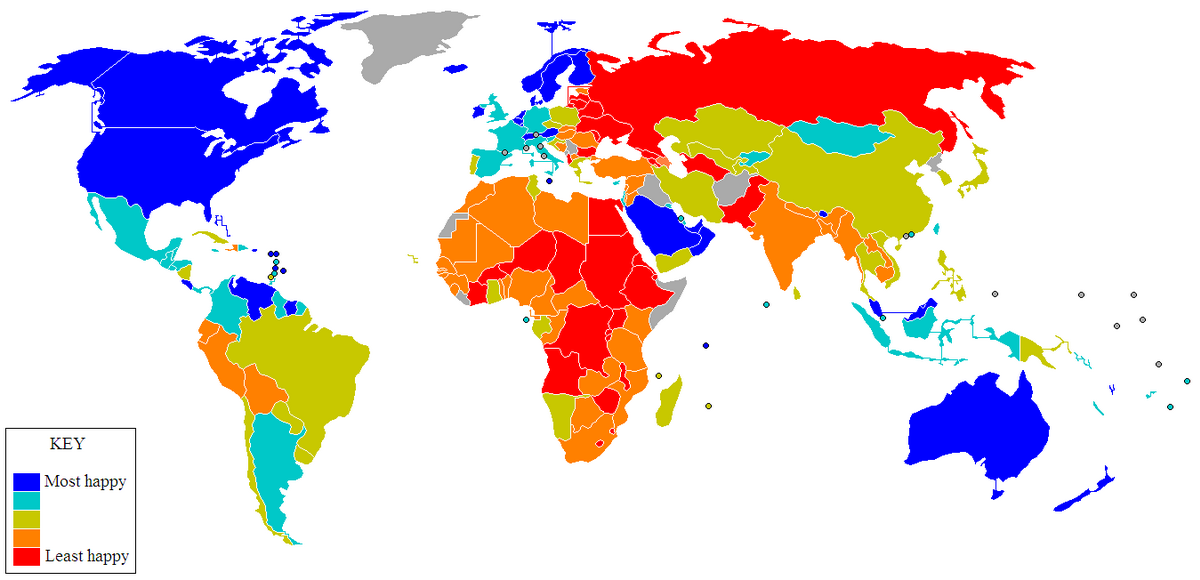

 ## Analysis Content
1. [Python Libraries](#1)
1. [Data Content](#2)
1. [Read and Analyse Date](#3)
1. [Data Distributions in 2021](#4)
1. [Happiest and Unhappiest Countries in 2021](#5)
1. [Ladder Score Distribution by Regional Indicator](#6)
1. [Ladder Score Distribution by Countries in Map View](#7)
1. [Most Generous and Ungenerous Countries in 2021](#8)
1. [Generous Distribution by Countries in Map View](#9)
1. [Generous Distribution by Regional Indicator in 2021](#10)
1. [Correlation Heatmap of Happiness Factors in 2021](#11)
1. [Relationship Between Happiness and Income](#12)
1. [Relationship Between Happiness and Income](#13)
1. [Relationship Between Happiness and Freedom](#14)
1. [Relationship Between Feautures](#14)

<a id="1"></a>
##  Python Libraries
* In this section, we import used libaries during this kernel.

In [164]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
plt.style.use("seaborn-notebook")

import warnings 
warnings.filterwarnings("ignore")


/kaggle/input/world-happiness-report-2021/world-happiness-report-2021.csv
/kaggle/input/world-happiness-report-2021/world-happiness-report.csv
/kaggle/input/world-population-19602018/population_total_long.csv
/kaggle/input/world-population-19602018/pop_worldometer_data.csv
/kaggle/input/world-population-19602018/population_above_age_65_percentage_long.csv
/kaggle/input/world-population-19602018/population_female_percentage_long.csv
/kaggle/input/world-population-19602018/population_below_age_14_percentage_long.csv
/kaggle/input/world-population-19602018/population_density_long.csv


<a id="2"></a>
## Data Content
* The happiness scores and rankings use data from the Gallup World Poll.
* Gallup World Poll: In 2005, Gallup began its World Poll, which continually surveys citizens in 160 countries, representing more than 98% of the world's adult population. The Gallup World Poll consists of more than 100 global questions as well as region-specific items.
* The columns following the happiness score estimate the extent to which each of six factors - economics production, social support, life expectancy, freedom, absence of corruption, and generosity- contribute the making life evalutions higher in each country than they are in Dystopia, a hypothetical country that has values equal to the world's lowest national averages for each of the six factors.
* **Ladder score:** Happiness score or subjective well-being. This is the national average response to the question of life evalutions.
*  **Logged GDP per capita: ** The GDP-per-capita time series from 2019 to 2020 using countryspecific forecasts of real GDP growth in 2020.
*  **Social support:** Social support refers to assistance or support provided by members of social networks to an indiviual.
*  **Healthy life expectancy:** Healthy life expectancy is the average life in good health - that is to say without irreversible limitation of activity in daily life or incapacities - of a fictitious generation subject to the conditions of morality and morbidity prevailing that year.
*  **Freedom to make life choices:** This indicator represents the national average of responses to the GWP question, "Are you satisfied with your freedom to choose what you do with your life?" It reflects how much control people feel they have over their own decisions and daily lives.
*  **Generosity:** Generosity is measured as the residual value obtained after regressing the national average response to the question "Have you donated money to a charity in the past month?" on GDP per capita. In other words, it captures the tendency to engage in charitable giving beyond what would be expected from income levels alone.
*  **Perceptions of corruption:** This score is based on the countrywide average of answers to two GWP questions: "Is corruption widespread throughout the government?" and "Is corruption widespread within businesses?". These responses reflect how pervasive people believe corruption is in both public and private sectors.
*  **Ladder score in Dystopia:** Dystopia: Dystopia is a hypothetical country created as a benchmark, representing the world's lowest values across all six factors. Since such a place would have the poorest income levels, shortest life expectancy, lowest generosity, highest corruption, least freedom, and weakest social support, it is used as a contrast to "Utopia" when comparing overall life evalutions.
*  World Happiness Report Official Website: https://worldhappiness.report/

<a id="3"></a>
## Read and Analyse Data

In [72]:
# read data
df = pd.read_csv("/kaggle/input/world-happiness-report-2021/world-happiness-report.csv")

In [73]:
# show first five row of data
df.head()

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.370,0.451,50.80,0.718,0.168,0.882,0.518,0.258
1,Afghanistan,2009,4.402,7.540,0.552,51.20,0.679,0.190,0.850,0.584,0.237
2,Afghanistan,2010,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275
3,Afghanistan,2011,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267
4,Afghanistan,2012,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268


In [74]:
# describe basic statistics of data
df.describe()

,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
count,1949.000000,1949.000000,1913.000000,1936.000000,1894.000000,1917.000000,1860.000000,1839.000000,1927.000000,1933.000000
mean,2013.216008,5.466705,9.368453,0.812552,63.359374,0.742558,0.000103,0.747125,0.710003,0.268544
std,4.166828,1.115711,1.154084,0.118482,7.510245,0.142093,0.162215,0.186789,0.107100,0.085168
min,2005.000000,2.375000,6.635000,0.290000,32.300000,0.258000,-0.335000,0.035000,0.322000,0.083000
25%,2010.000000,4.640000,8.464000,0.749750,58.685000,0.647000,-0.113000,0.690000,0.625500,0.206000
50%,2013.000000,5.386000,9.460000,0.835500,65.200000,0.763000,-0.025500,0.802000,0.722000,0.258000
75%,2017.000000,6.283000,10.353000,0.905000,68.590000,0.856000,0.091000,0.872000,0.799000,0.320000
max,2020.000000,8.019000,11.648000,0.987000,77.100000,0.985000,0.698000,0.983000,0.944000,0.705000


In [75]:
# information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1949 entries, 0 to 1948
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      1949 non-null   object 
 1   year                              1949 non-null   int64  
 2   Life Ladder                       1949 non-null   float64
 3   Log GDP per capita                1913 non-null   float64
 4   Social support                    1936 non-null   float64
 5   Healthy life expectancy at birth  1894 non-null   float64
 6   Freedom to make life choices      1917 non-null   float64
 7   Generosity                        1860 non-null   float64
 8   Perceptions of corruption         1839 non-null   float64
 9   Positive affect                   1927 non-null   float64
 10  Negative affect                   1933 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 167.6+ KB


In [76]:
# read data 
df2021 = pd.read_csv("/kaggle/input/world-happiness-report-2021/world-happiness-report-2021.csv")

In [77]:
# show first five rows of data
df2021.head()

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


In [78]:
# describe basic statistics of data
df2021.describe()

,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,1.490000e+02,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.532839,0.058752,5.648007,5.417631,9.432208,0.814745,64.992799,0.791597,-0.015134,0.727450,2.430000e+00,0.977161,0.793315,0.520161,0.498711,0.178047,0.135141,2.430329
std,1.073924,0.022001,1.054330,1.094879,1.158601,0.114889,6.762043,0.113332,0.150657,0.179226,5.347044e-15,0.404740,0.258871,0.213019,0.137888,0.098270,0.114361,0.537645
min,2.523000,0.026000,2.596000,2.449000,6.635000,0.463000,48.478000,0.382000,-0.288000,0.082000,2.430000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.648000
25%,4.852000,0.043000,4.991000,4.706000,8.541000,0.750000,59.802000,0.718000,-0.126000,0.667000,2.430000e+00,0.666000,0.647000,0.357000,0.409000,0.105000,0.060000,2.138000
50%,5.534000,0.054000,5.625000,5.413000,9.569000,0.832000,66.603000,0.804000,-0.036000,0.781000,2.430000e+00,1.025000,0.832000,0.571000,0.514000,0.164000,0.101000,2.509000
75%,6.255000,0.070000,6.344000,6.128000,10.421000,0.905000,69.600000,0.877000,0.079000,0.845000,2.430000e+00,1.323000,0.996000,0.665000,0.603000,0.239000,0.174000,2.794000
max,7.842000,0.173000,7.904000,7.780000,11.647000,0.983000,76.953000,0.970000,0.542000,0.939000,2.430000e+00,1.751000,1.172000,0.897000,0.716000,0.541000,0.547000,3.482000


In [79]:
# information about data
df2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 20 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                149 non-null    object 
 1   Regional indicator                          149 non-null    object 
 2   Ladder score                                149 non-null    float64
 3   Standard error of ladder score              149 non-null    float64
 4   upperwhisker                                149 non-null    float64
 5   lowerwhisker                                149 non-null    float64
 6   Logged GDP per capita                       149 non-null    float64
 7   Social support                              149 non-null    float64
 8   Healthy life expectancy                     149 non-null    float64
 9   Freedom to make life choices                149 non-null    float64
 10  Generosity    

<a id="4"></a>
## Data Distributions in 2021
* Unique Countries
* Count Regional Indicator
* Distribution of Remaining Features

In [80]:
#unique countries 
df2021['Country name'].unique()

array(['Finland', 'Denmark', 'Switzerland', 'Iceland', 'Netherlands',
       'Norway', 'Sweden', 'Luxembourg', 'New Zealand', 'Austria',
       'Australia', 'Israel', 'Germany', 'Canada', 'Ireland',
       'Costa Rica', 'United Kingdom', 'Czech Republic', 'United States',
       'Belgium', 'France', 'Bahrain', 'Malta',
       'Taiwan Province of China', 'United Arab Emirates', 'Saudi Arabia',
       'Spain', 'Italy', 'Slovenia', 'Guatemala', 'Uruguay', 'Singapore',
       'Kosovo', 'Slovakia', 'Brazil', 'Mexico', 'Jamaica', 'Lithuania',
       'Cyprus', 'Estonia', 'Panama', 'Uzbekistan', 'Chile', 'Poland',
       'Kazakhstan', 'Romania', 'Kuwait', 'Serbia', 'El Salvador',
       'Mauritius', 'Latvia', 'Colombia', 'Hungary', 'Thailand',
       'Nicaragua', 'Japan', 'Argentina', 'Portugal', 'Honduras',
       'Croatia', 'Philippines', 'South Korea', 'Peru',
       'Bosnia and Herzegovina', 'Moldova', 'Ecuador', 'Kyrgyzstan',
       'Greece', 'Bolivia', 'Mongolia', 'Paraguay', 'Montenegro

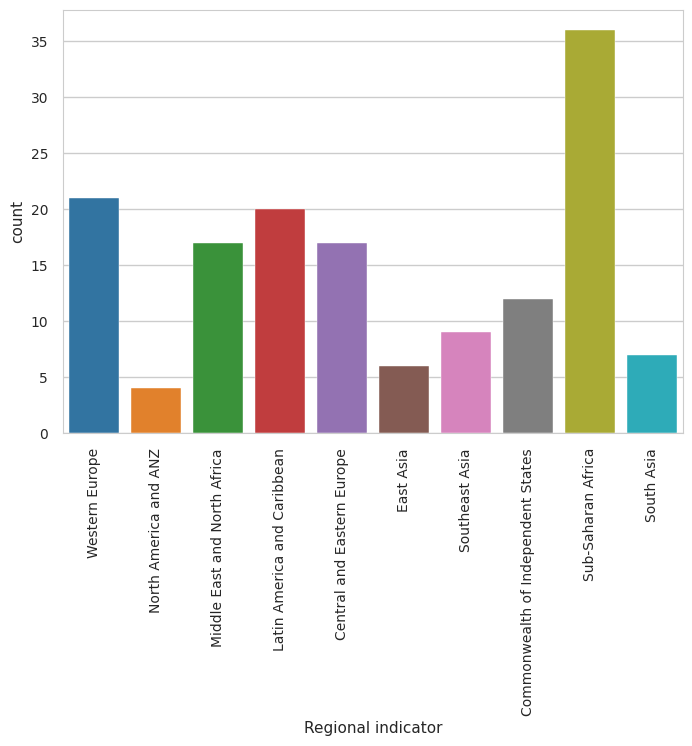

In [81]:
# count regional indicator
sns.countplot(x=df2021["Regional indicator"])
plt.xticks(rotation=90)
plt.show()

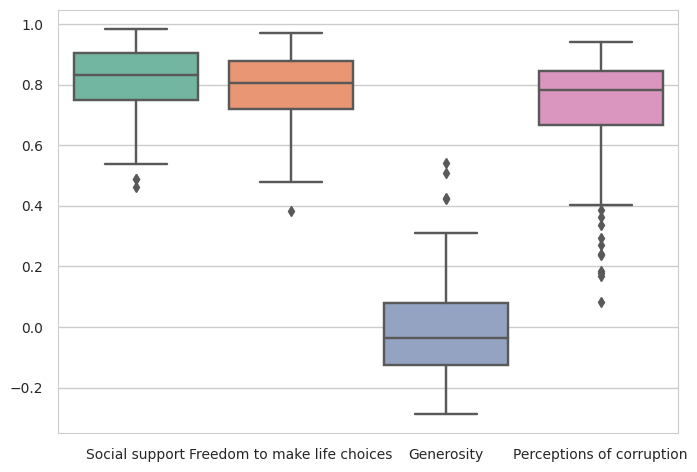

In [82]:
# distribution of feature set 1
list_features = ["Social support", "Freedom to make life choices", "Generosity",  "Perceptions of corruption"]
sns.boxplot(data = df2021.loc[:, list_features], orient = "v", palette = "Set2")
plt.show()

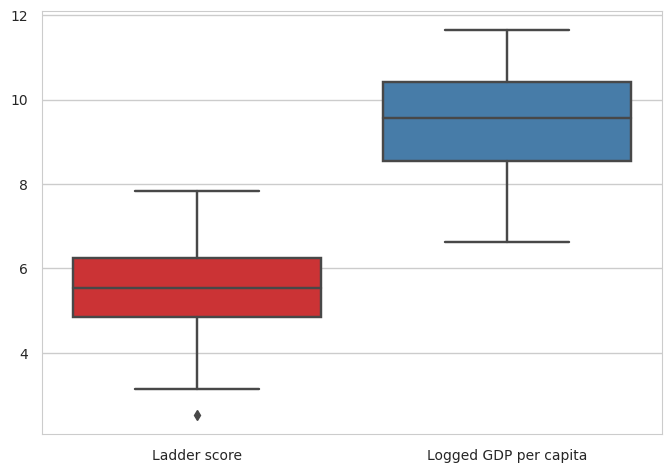

In [83]:
# distribution of feauture set 2
list_features = ["Ladder score", "Logged GDP per capita"]
sns.boxplot(data=df2021.loc[:,list_features], orient = "v", palette ="Set1")
plt.show()

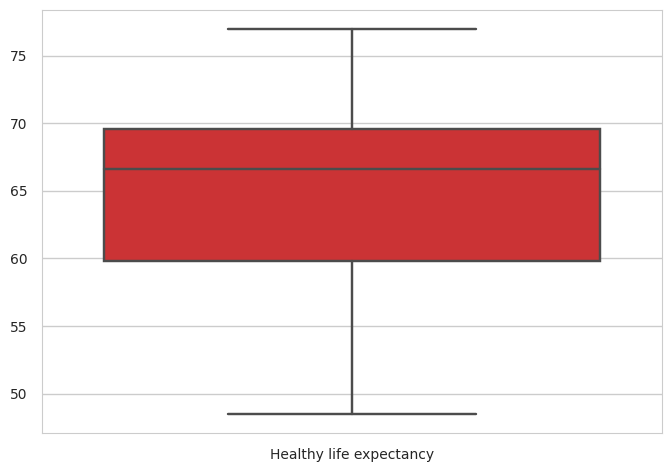

In [84]:
 # distribution of feature set 3
list_features = ["Healthy life expectancy"]
sns.boxplot(data=df2021.loc[:, list_features], orient = "v" ,  palette ="Set1") 
plt.show()

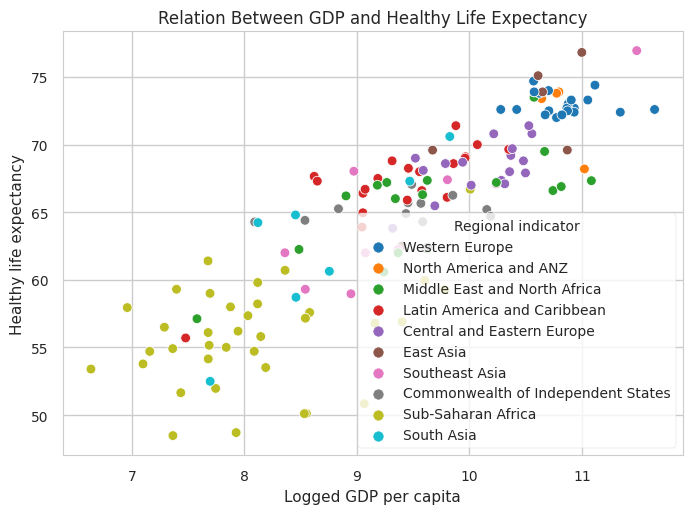

In [85]:
sns.scatterplot(data=df2021, x = "Logged GDP per capita", y = "Healthy life expectancy", hue ="Regional indicator")
plt.title("Relation Between GDP and Healthy Life Expectancy")
plt.show()

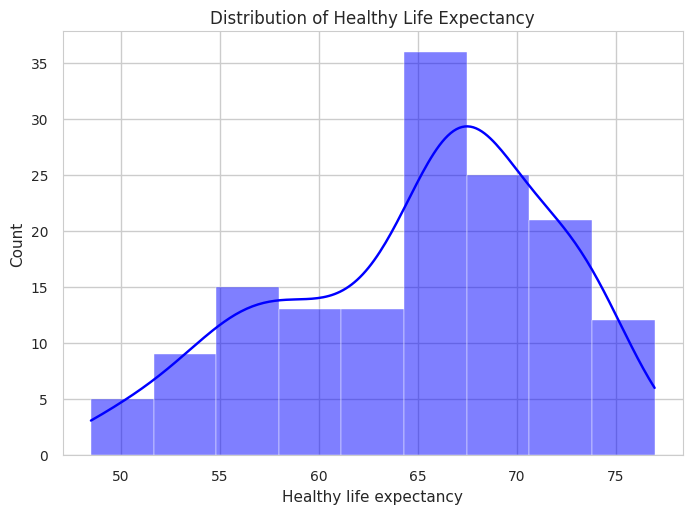

In [86]:
sns.histplot(df2021["Healthy life expectancy"], kde=True, color="blue")
plt.title("Distribution of Healthy Life Expectancy")
plt.show()

<a id="5"></a>
## Happiest and Unhappiest Countries in 2021

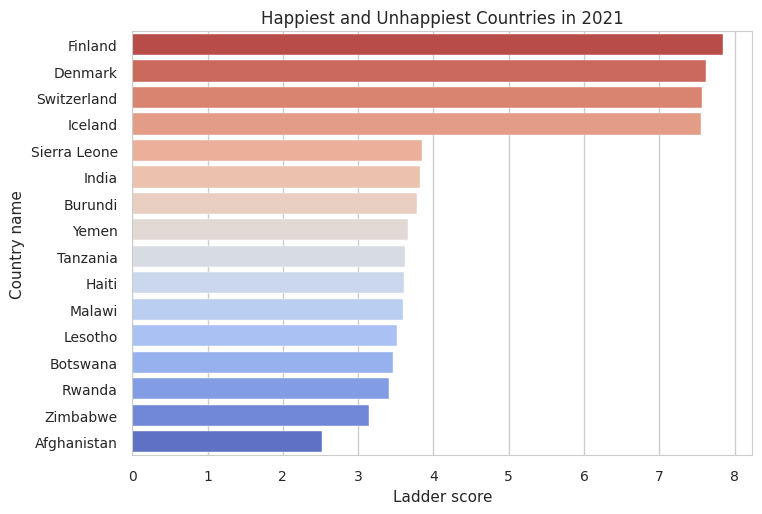

In [87]:
df2021_happiest_unhappiest = df2021[(df2021.loc[:, "Ladder score"] > 7.5) | (df2021.loc[:, "Ladder score"] < 4)]
sns.barplot(x="Ladder score" , y = "Country name", data=df2021_happiest_unhappiest, palette="coolwarm_r")
plt.title("Happiest and Unhappiest Countries in 2021")
plt.show()

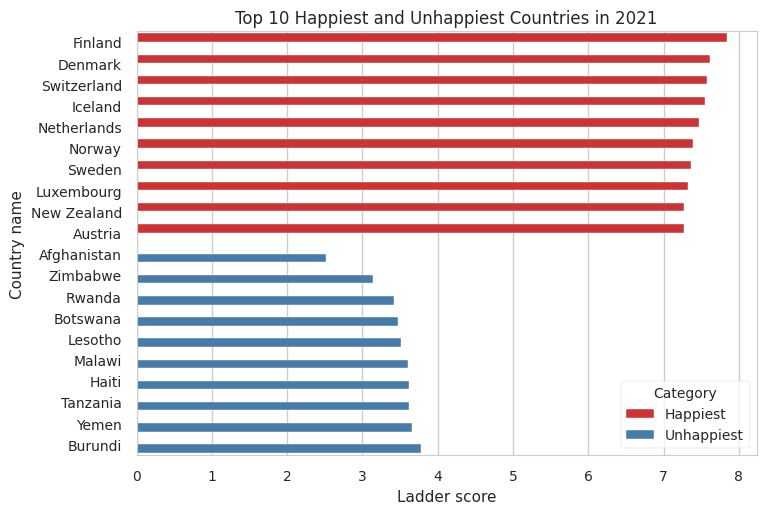

In [88]:
# Combine happiest and unhappiest
top10= df2021.nlargest(10, "Ladder score")
bottom10 = df2021.nsmallest(10, "Ladder score")
combined = pd.concat([top10, bottom10])
combined['Category'] = ["Happiest"]*10 +  ["Unhappiest"]*10
sns.barplot(data=combined, x="Ladder score", y ="Country name", hue="Category", palette = "Set1")
plt.title("Top 10 Happiest and Unhappiest Countries in 2021")

plt.show()

<a id="6"></a>
## Ladder Score Distribution by Regional Indicator

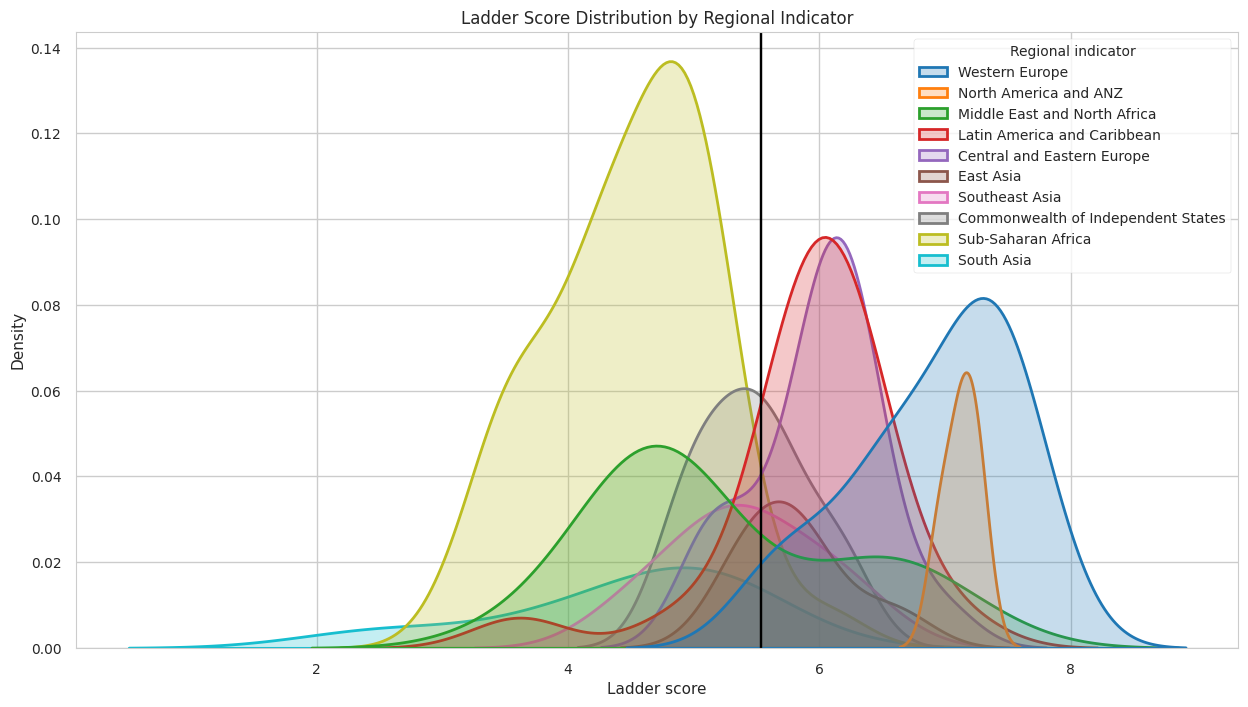

In [89]:
plt.figure(figsize = (15,8))
sns.kdeplot(data=df2021, x="Ladder score", hue= "Regional indicator", fill = True, linewidth = 2)
# mean line
plt.axvline(df2021["Ladder score"].mean(), c ="black")
plt.title("Ladder Score Distribution by Regional Indicator")
plt.show()

<a id="7"></a>
## Ladder Score Distribution by Countries in Map View

In [90]:
df.head(1)

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.37,0.451,50.8,0.718,0.168,0.882,0.518,0.258


In [91]:
fig = px.choropleth(df.sort_values("year"), locations = "Country name", color = "Life Ladder" , locationmode = "country names", 
animation_frame = "year")
fig.update_layout(title = "Life Ladder Comparison by Countries")
fig.show()

<a id="8"></a>
## Most Generous and Ungenerous Countries In 2021

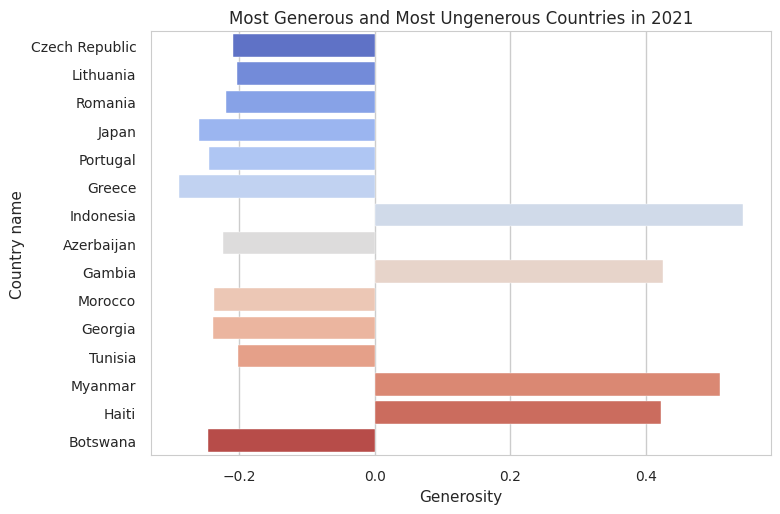

In [92]:
df2021_g = df2021[(df2021.loc[:, "Generosity"] > 0.4) | (df2021.loc[:, "Generosity"] < -0.2)]
sns.barplot(x= "Generosity", y = "Country name", data = df2021_g, palette ="coolwarm")
plt.title("Most Generous and Most Ungenerous Countries in 2021")
plt.show()

<a id="9"></a>
## Generous Distribution By Countries In Map View

In [93]:
fig = px.choropleth(df.sort_values("year"), locations = "Country name", color = "Generosity", locationmode = "country names" , 
animation_frame = "year")
fig.update_layout(title = "Generosity Comparison by Countries")
fig.show()

<a id="10"></a>
## Generous Distribution by Regional Indicator in 2021

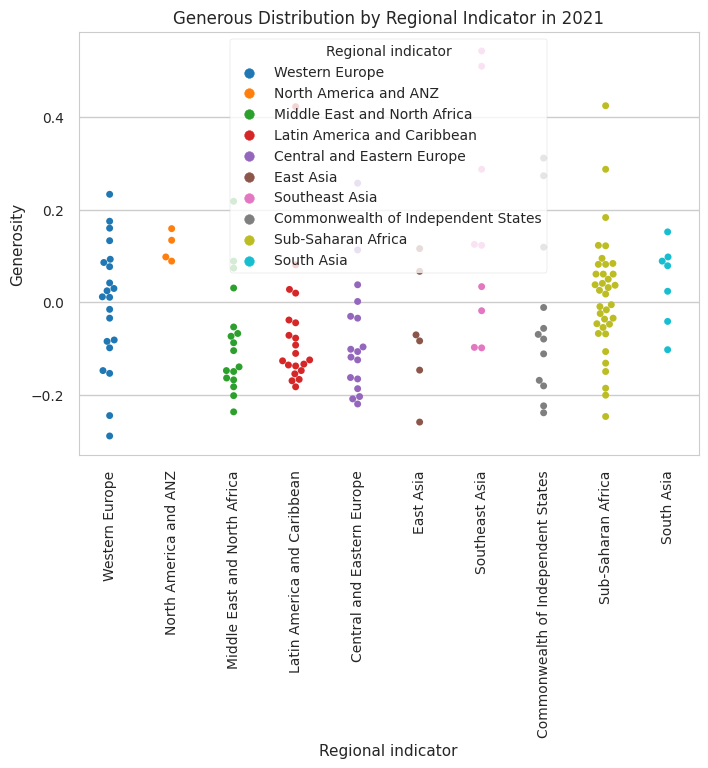

In [94]:
sns.swarmplot(x = "Regional indicator", y = "Generosity", hue = "Regional indicator", data = df2021)
plt.xticks(rotation = 90)
plt.title("Generous Distribution by Regional Indicator in 2021")
plt.show()


<a id="11"></a>
## Correlation Heatmap of Happiness Fcators in 2021

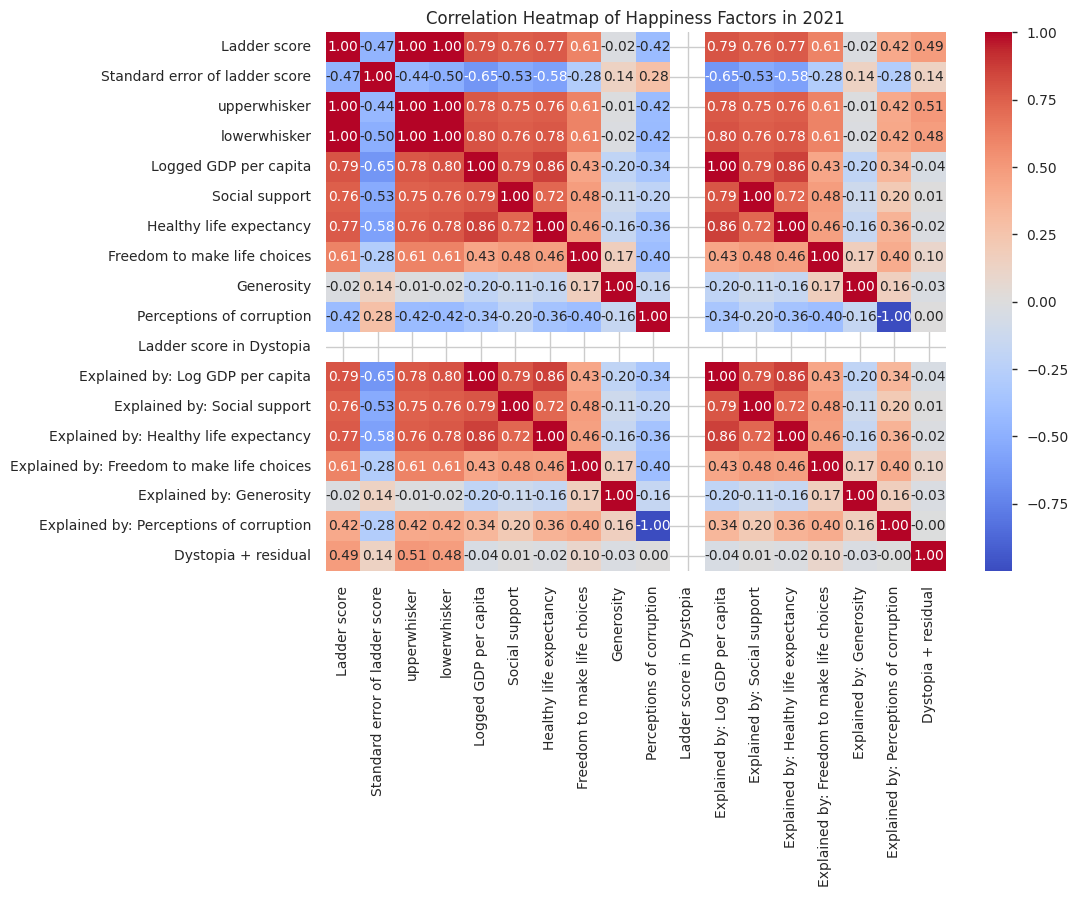

In [95]:
numeric_df = df2021.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Happiness Factors in 2021")
plt.show()

<a id="12"></a>
## Relationship Between Happiness and Income

In [96]:
pop = pd.read_csv("/kaggle/input/world-population-19602018/population_total_long.csv")
pop.head()

,Country Name,Year,Count
0,Aruba,1960,54211
1,Afghanistan,1960,8996973
2,Angola,1960,5454933
3,Albania,1960,1608800
4,Andorra,1960,13411


In [97]:
pop.tail()

,Country Name,Year,Count
12590,Kosovo,2017,1830700
12591,"Yemen, Rep.",2017,27834821
12592,South Africa,2017,57000451
12593,Zambia,2017,16853688
12594,Zimbabwe,2017,14236745


In [98]:
df["Country name"].value_counts()

Country name
Zimbabwe        15
South Africa    15
Tanzania        15
Denmark         15
Tajikistan      15
                ..
Maldives         1
Suriname         1
Cuba             1
Oman             1
Guyana           1
Name: count, Length: 166, dtype: int64

In [99]:
country_continent = {}

for i in range(len(df2021)):
    country_continent[df2021["Country name"][i]] = df2021["Regional indicator"][i]

all_countries = df2021["Country name"].value_counts().reset_index()["Country name"].tolist()
all_countries_2021 = df2021["Country name"].value_counts().reset_index()["Country name"].tolist()

for x in all_countries:
    if x not in all_countries_2021:
        print(x)

In [100]:
print(df2021.columns)

Index(['Country name', 'Regional indicator', 'Ladder score',
       'Standard error of ladder score', 'upperwhisker', 'lowerwhisker',
       'Logged GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Ladder score in Dystopia',
       'Explained by: Log GDP per capita', 'Explained by: Social support',
       'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')


In [103]:
print(df2021.columns)

Index(['Country name', 'Regional indicator', 'Ladder score',
       'Standard error of ladder score', 'upperwhisker', 'lowerwhisker',
       'Logged GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Ladder score in Dystopia',
       'Explained by: Log GDP per capita', 'Explained by: Social support',
       'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')


In [102]:
df2021.head(10)

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
5,Norway,Western Europe,7.392,0.035,7.462,7.323,11.053,0.954,73.3,0.960,0.093,0.270,2.43,1.543,1.108,0.782,0.703,0.249,0.427,2.580
6,Sweden,Western Europe,7.363,0.036,7.433,7.293,10.867,0.934,72.7,0.945,0.086,0.237,2.43,1.478,1.062,0.763,0.685,0.244,0.448,2.683
7,Luxembourg,Western Europe,7.324,0.037,7.396,7.252,11.647,0.908,72.6,0.907,-0.034,0.386,2.43,1.751,1.003,0.760,0.639,0.166,0.353,2.653
8,New Zealand,North America and ANZ,7.277,0.040,7.355,7.198,10.643,0.948,73.4,0.929,0.134,0.242,2.43,1.400,1.094,0.785,0.665,0.276,0.445,2.612
9,Austria,Western Europe,7.268,0.036,7.337,7.198,10.906,0.934,73.3,0.908,0.042,0.481,2.43,1.492,1.062,0.782,0.640,0.215,0.292,2.784


In [114]:
print(df2021.columns)
print(df.columns)
print(pop.columns)

Index(['country name', 'regional indicator', 'ladder score',
       'standard error of ladder score', 'upperwhisker', 'lowerwhisker',
       'logged gdp per capita', 'social support', 'healthy life expectancy',
       'freedom to make life choices', 'generosity',
       'perceptions of corruption', 'ladder score in dystopia',
       'explained by: log gdp per capita', 'explained by: social support',
       'explained by: healthy life expectancy',
       'explained by: freedom to make life choices',
       'explained by: generosity', 'explained by: perceptions of corruption',
       'dystopia + residual'],
      dtype='object')
Index(['country name', 'year', 'life ladder', 'log gdp per capita',
       'social support', 'healthy life expectancy at birth',
       'freedom to make life choices', 'generosity',
       'perceptions of corruption', 'positive affect', 'negative affect'],
      dtype='object')
Index(['country name', 'year', 'count'], dtype='object')


In [115]:
## step 1: normalize column names(lowercase and remove spaces) 

df2021.columns = df2021.columns.str.lower().str.strip()
df.columns = df.columns.str.lower().str.strip()
pop.columns = pop.columns.str.lower().str.strip()

print(df2021.columns)
print(df.columns)
print(pop.columns)

Index(['country name', 'regional indicator', 'ladder score',
       'standard error of ladder score', 'upperwhisker', 'lowerwhisker',
       'logged gdp per capita', 'social support', 'healthy life expectancy',
       'freedom to make life choices', 'generosity',
       'perceptions of corruption', 'ladder score in dystopia',
       'explained by: log gdp per capita', 'explained by: social support',
       'explained by: healthy life expectancy',
       'explained by: freedom to make life choices',
       'explained by: generosity', 'explained by: perceptions of corruption',
       'dystopia + residual'],
      dtype='object')
Index(['country name', 'year', 'life ladder', 'log gdp per capita',
       'social support', 'healthy life expectancy at birth',
       'freedom to make life choices', 'generosity',
       'perceptions of corruption', 'positive affect', 'negative affect'],
      dtype='object')
Index(['country name', 'year', 'count'], dtype='object')


In [116]:
## step 2 : create mapping dictionary for country to region
country_continent = dict(zip(df2021["country name"], df2021["regional indicator"]))

In [117]:
## step 3 : add region to column to df(world happiness dataset)
df["region"] = df["country name"].map(country_continent)

In [118]:
## step 4 : add region column to population dataset
pop["region"] = pop["country name"].map(country_continent)

In [119]:
df.head()

,country name,year,life ladder,log gdp per capita,social support,healthy life expectancy at birth,freedom to make life choices,generosity,perceptions of corruption,positive affect,negative affect,region
0,Afghanistan,2008,3.724,7.370,0.451,50.80,0.718,0.168,0.882,0.518,0.258,South Asia
1,Afghanistan,2009,4.402,7.540,0.552,51.20,0.679,0.190,0.850,0.584,0.237,South Asia
2,Afghanistan,2010,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275,South Asia
3,Afghanistan,2011,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267,South Asia
4,Afghanistan,2012,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268,South Asia


In [120]:
## manual mapping check
region = []

for i in range(len(df)):
    country = df["country name"].iloc[i]

    if country == "Angola":
        region.append("Sub-Saharan Africa")
    elif country == "Belize":
        region.append("Latin America and Caribbean")
    elif country == "Congo (Kinshasa)":
        region.append("Sub-Saharan Africa")
    elif country == "Syria":
        region.append("Middle East and North Africa")
    elif country == "Trinidad and Tobago":
        region.append("Latin America and Caribbean")
    elif country == "Qatar":
        region.append("Middle East and North Africa")
    elif country == "Central African Republic":
        region.append("Sub-Saharan Africa")
    elif country == "Djibouti":
        region.append("Sub-Saharan Africa")
    elif country == "Somaliland region":
        region.append("Sub-Saharan Africa")
    elif country == "Somalia":
        region.append("Sub-Saharan Africa")
    elif country == "South Sudan":
        region.append("Sub-Saharan Africa")
    elif country == "Oman":
        region.append("Middle East and North Africa")
    elif country == "Guyana":
        region.append("Latin America and Caribbean")
    elif country == "Bhutan":
        region.append("South Asia")
    elif country == "Suriname":
        region.append("Latin America and Caribbean")
    else:
        
        region.append(df["region"].iloc[i])

df["region_manual"] = region

In [121]:
df.head()

,country name,year,life ladder,log gdp per capita,social support,healthy life expectancy at birth,freedom to make life choices,generosity,perceptions of corruption,positive affect,negative affect,region,region_manual
0,Afghanistan,2008,3.724,7.370,0.451,50.80,0.718,0.168,0.882,0.518,0.258,South Asia,South Asia
1,Afghanistan,2009,4.402,7.540,0.552,51.20,0.679,0.190,0.850,0.584,0.237,South Asia,South Asia
2,Afghanistan,2010,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275,South Asia,South Asia
3,Afghanistan,2011,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267,South Asia,South Asia
4,Afghanistan,2012,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268,South Asia,South Asia


In [122]:
df.tail()

,country name,year,life ladder,log gdp per capita,social support,healthy life expectancy at birth,freedom to make life choices,generosity,perceptions of corruption,positive affect,negative affect,region,region_manual
1944,Zimbabwe,2016,3.735,7.984,0.768,54.4,0.733,-0.095,0.724,0.738,0.209,Sub-Saharan Africa,Sub-Saharan Africa
1945,Zimbabwe,2017,3.638,8.016,0.754,55.0,0.753,-0.098,0.751,0.806,0.224,Sub-Saharan Africa,Sub-Saharan Africa
1946,Zimbabwe,2018,3.616,8.049,0.775,55.6,0.763,-0.068,0.844,0.710,0.212,Sub-Saharan Africa,Sub-Saharan Africa
1947,Zimbabwe,2019,2.694,7.950,0.759,56.2,0.632,-0.064,0.831,0.716,0.235,Sub-Saharan Africa,Sub-Saharan Africa
1948,Zimbabwe,2020,3.160,7.829,0.717,56.8,0.643,-0.009,0.789,0.703,0.346,Sub-Saharan Africa,Sub-Saharan Africa


In [123]:
print(df.columns)

Index(['country name', 'year', 'life ladder', 'log gdp per capita',
       'social support', 'healthy life expectancy at birth',
       'freedom to make life choices', 'generosity',
       'perceptions of corruption', 'positive affect', 'negative affect',
       'region', 'region_manual'],
      dtype='object')


In [125]:
data = df2021.copy()

In [137]:
data = df2021.copy()

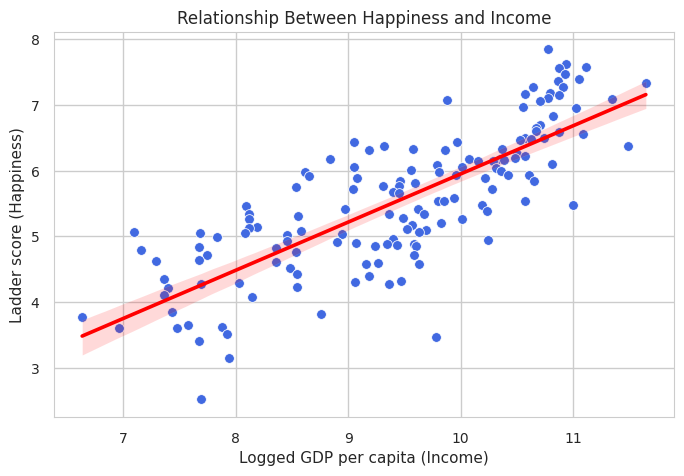

In [139]:
data = df2021.copy()

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="logged gdp per capita",
    y="ladder score",
    color="royalblue"
)

sns.regplot(
    data=data,
    x="logged gdp per capita",
    y="ladder score",
    scatter=False,
    color="red"
)

plt.title("Relationship Between Happiness and Income")
plt.xlabel("Logged GDP per capita (Income)")
plt.ylabel("Ladder score (Happiness)")
plt.show()


<a id="13"></a>
 ## Relationship Between Happiness and Freedom

In [146]:
## column checking 
print(pop.columns)

Index(['country name', 'year', 'count', 'region'], dtype='object')


In [154]:
print(df.dtypes)

country name                         object
year                                  int64
life ladder                         float64
log gdp per capita                  float64
social support                      float64
healthy life expectancy at birth    float64
freedom to make life choices        float64
generosity                          float64
perceptions of corruption           float64
positive affect                     float64
negative affect                     float64
region                               object
region_manual                        object
dtype: object


In [162]:
print(df.columns)

Index(['country name', 'year', 'life ladder', 'log gdp per capita',
       'social support', 'healthy life expectancy at birth',
       'freedom to make life choices', 'generosity',
       'perceptions of corruption', 'positive affect', 'negative affect',
       'region', 'region_manual'],
      dtype='object')


In [165]:
## Animated scatter plot
## This visualization illustrates the relation between happiness(ladder score) and freedom
import plotly.express as px

fig = px.scatter(
    df,
    x="freedom to make life choices",
    y="life ladder",
    animation_frame="year",
    animation_group="country name",
    color="region",
    hover_name="country name",
    size_max=45,
    template="plotly_dark"
)

fig.update_layout(
    title="Animated Relationship Between Happiness and Freedom Across Countries",
    xaxis_title="Freedom to Make Life Choices",
    yaxis_title="Life Ladder (Happiness Score)"
)

fig.show()

<a id="14"></a>
 ## Relationship Between Happiness and Corruption

In [166]:
# Animated Scatter Plot: This visualization explores the relationship between perceived corruption levels 
# and overall happiness (Life Ladder score) across countries over time.
# Higher corruption scores indicate greater perceived corruption.
# Each point is a country, colored by region. The animation slider shows how
# corruption and happiness change year by year. Hover labels display country names
# for easier comparison.
fig = px.scatter(
    df,  
    x="perceptions of corruption",          # X axis: corruption perception
    y="life ladder",                        # Y axis: happiness score
    animation_frame="year",                 # animasyon yılı
    animation_group="country name",
    color="region",                         # bölgelere göre renk
    hover_name="country name",              # hover’da ülke ismi
    size_max=50,                            
    template="plotly_dark"
)

fig.update_layout(
    title="Relationship Between Happiness and Corruption Across Countries (Animated)",
    xaxis_title="Perceptions of Corruption (Higher = More Corruption)",
    yaxis_title="Life Ladder (Happiness Score)"
)

fig.show()


<a id="14"></a>
 ## Relationship Between Feautures

In [170]:
# FEATURES RELEVANT TO CORRUPTION
features = [
    "life ladder",
    "freedom to make life choices",
    "perceptions of corruption"
]

# CORRELATION MATRIX
corr_table = df[features].corr().round(3)

corr_table

,life ladder,freedom to make life choices,perceptions of corruption
life ladder,1.000,0.528,-0.427
freedom to make life choices,0.528,1.000,-0.488
perceptions of corruption,-0.427,-0.488,1.000


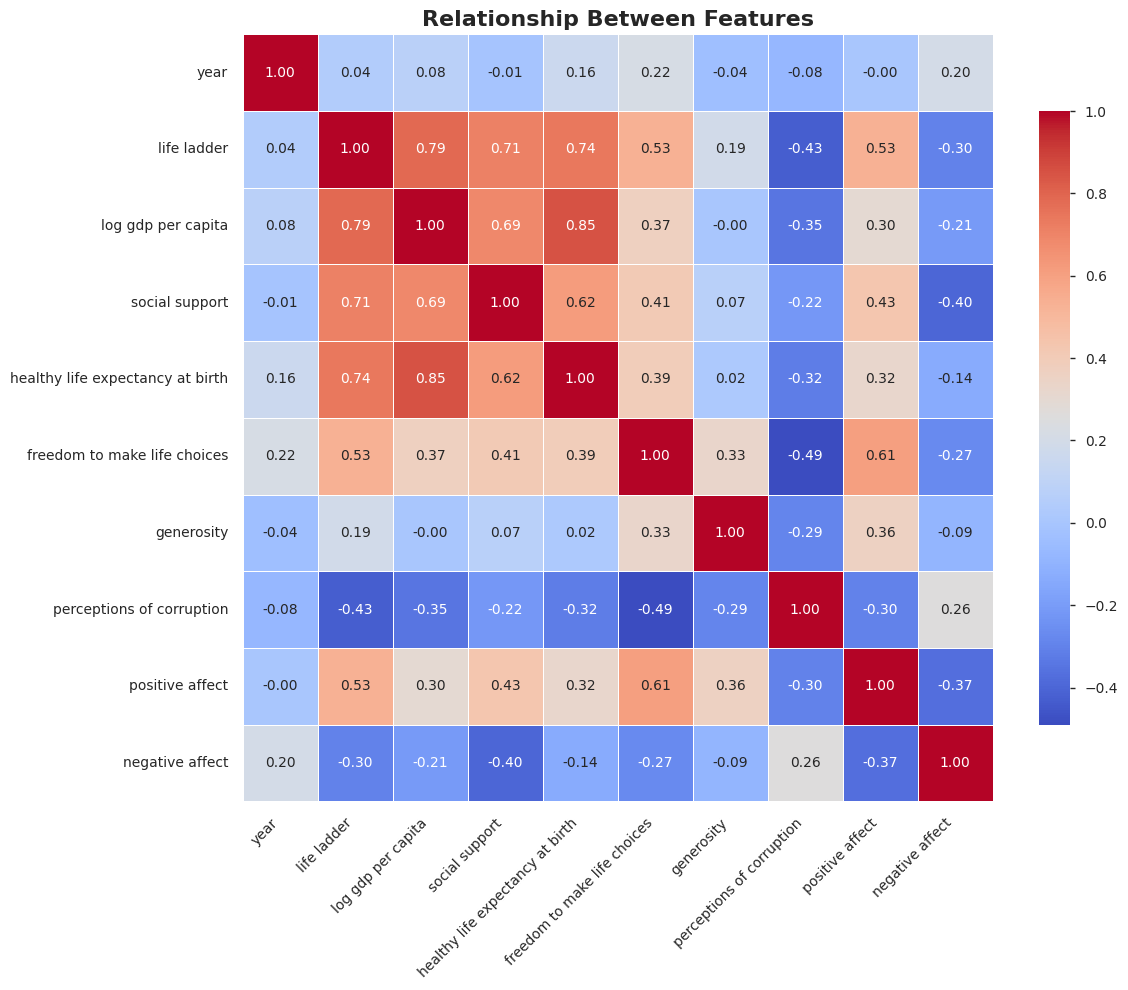

In [172]:
# with numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# creating corelation matrices
corr = numeric_df.corr().round(2)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Relationship Between Features", fontsize=16, weight="bold")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()